# 06. 라우터 패턴 (Router Pattern)

> 라우터는 입력을 분류해 적절한 에이전트들에게 **병렬 분배**해요. 이 노트북은 `Send` 자체를 다시 배우는 단원이 아니라, 이미 배운 동적 병렬 분기를 멀티 에이전트 라우팅에 적용하는 단원이에요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 라우터 패턴의 핵심 개념과 동작 방식을 설명할 수 있어요
2. `with_structured_output`으로 입력을 분류하는 분류기(Classifier)를 구현할 수 있어요
3. `Send`로 분류 결과를 여러 도메인 에이전트에 병렬 분배할 수 있어요
4. `Annotated[list, operator.add]`로 병렬 실행 결과를 안전하게 집계할 수 있어요
5. 결과 합성(Synthesis) 노드로 여러 에이전트의 응답을 통합할 수 있어요

## 사전 지식

- `02_LangGraph_Basics/04-StateGraph-Basics.ipynb`: `Send`, reducer, 조건부 엣지 기초
- `03_Thinking_in_LangGraph/01-Workflows-vs-Agents.ipynb`: Orchestrator-Worker에서 `Send`를 쓰는 이유
- `05_Agent_Development/01-Create-Agent.ipynb`: `create_agent` 함수 사용법
- 이전 노트북 `05-Handoffs.ipynb`: 상태 변수 기반 에이전트 전환


## 라우터 패턴이란?

라우터 패턴(Router Pattern)은 **입력을 먼저 분류한 뒤, 해당 도메인의 전문 에이전트에게 작업을 분배**하는 멀티 에이전트 아키텍처예요.

> 💡 **핵심 정리**: 라우터 패턴은 **우체국 분류 시스템**과 같아요. 편지(사용자 쿼리)가 도착하면 분류기(Classifier)가 목적지를 나누고, 각 지역 배달부(전문 에이전트)가 동시에 출발해요.

핵심 아이디어는 세 단계예요:

1. **분류(Classification)**: 사용자 쿼리를 분석해 필요한 도메인 목록을 만들어요
2. **분배(Dispatch)**: 이미 배운 `Send`로 관련 에이전트에게 작업을 병렬 전달해요
3. **합성(Synthesis)**: 각 에이전트의 응답을 하나로 통합해 최종 답변을 만들어요

| 단계 | 역할 | LangGraph 구현 | 이 노트북의 초점 |
|------|------|----------------|------------------|
| 분류기 | 쿼리 → (소스, 쿼리) 쌍 목록 생성 | `with_structured_output(ClassificationResult)` | 라우터용 출력 스키마 설계 |
| 라우팅 함수 | 소스별로 에이전트에 작업 분배 | `Send(node_name, state_dict)` | 분류 결과를 도메인 에이전트 입력으로 변환 |
| 도메인 에이전트 | 각 소스에 특화된 검색/처리 | `create_agent` | 역할별 도구와 프롬프트 분리 |
| 합성기 | 복수 결과 → 단일 응답 | 결과 합성 노드 | 응답 일관성 유지 |

> 🔑 **핵심 개념**: 여기서 새로 배우는 것은 `Send` 문법이 아니라 **경량 분류기 + 특화 실행기 + 결과 합성**이라는 라우터 설계입니다. `Send` 문법이 헷갈리면 Part 02의 StateGraph 기초를 먼저 확인해요.


## 전체 아키텍처

```mermaid
flowchart TD
    A(["사용자 쿼리<br>User Query"]) --> B["분류 노드<br>classify"]
    B -->|"Send(github_agent, ...)"| C["GitHub 에이전트<br>github_agent"]
    B -->|"Send(notion_agent, ...)"| D["Notion 에이전트<br>notion_agent"]
    B -->|"Send(slack_agent, ...)"| E["Slack 에이전트<br>slack_agent"]
    C -->|"결과 추가"| F["합성 노드<br>synthesize"]
    D -->|"결과 추가"| F
    E -->|"결과 추가"| F
    F --> G(["최종 응답<br>Final Response"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef agent fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef output fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,F process
    class C,D,E agent
    class G output
```

> 💡 **핵심 정리**: 다이어그램에서 `classify` 노드 하나가 여러 에이전트로 분기하는 구조를 주목해요. 이 분기가 **순차가 아닌 병렬**로 실행돼요. `Send` API가 이를 가능하게 해요.

## 환경 설정

In [48]:
# 환경 변수를 로드해요 (OPENAI_API_KEY 등)
from dotenv import load_dotenv
load_dotenv()

True

In [49]:
# LangSmith 추적을 설정해요 (선택사항이지만 디버깅에 유용해요)
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Router-Pattern"

## 1. Router에서 `Send`를 쓰는 이유

`Send`의 기본 문법과 reducer 규칙은 `02_LangGraph_Basics/04-StateGraph-Basics.ipynb`에서 이미 배웠어요. 여기서는 그 문법을 다시 설명하기보다, 라우터 패턴에서 `Send`가 맡는 역할만 짚고 넘어갑니다.

```python
def route_to_agents(state) -> list[Send]:
    return [
        Send(item.source + "_agent", {"query": item.query})
        for item in state["classification"].items
    ]
```

라우터에서 `Send`가 필요한 이유는 세 가지예요:

| 라우터 요구사항 | `Send`가 해결하는 방식 |
|---|---|
| 어떤 에이전트가 필요할지 런타임에 결정됨 | 분류 결과를 보고 보낼 노드를 동적으로 선택 |
| 여러 도메인을 동시에 조회해야 함 | `Send` 목록을 반환해 병렬 실행 |
| 에이전트별 입력이 서로 다름 | 각 `Send(node, state_dict)`에 맞춤 상태 전달 |

> ⚠️ **복습 포인트**: 병렬 결과를 모으려면 `Annotated[list, operator.add]` 같은 집계 reducer가 필요해요. 이 노트북에서는 그 규칙을 라우터 결과 집계에 적용합니다.


In [50]:
import operator  # operator.add: 리스트 병합 리듀서로 사용
from typing import Annotated, TypedDict
# LangGraph 핵심 구성 요소
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send  # 동적 병렬 분배를 위한 Send

def route_to_agents(state) -> list[Send]:
    return [
        Send(item.source + "_agent", {"query": item.query})
        for item in state["classification"].sources
    ]


## 2. 상태(State) 설계

라우터 패턴에서는 세 가지 상태 구조가 필요해요:

| 상태 클래스 | 역할 | 특징 |
|------------|------|------|
| `OverallState` | 전체 워크플로우 상태 | `results` 필드에 집계 리듀서 사용 |
| `AgentState` | 각 도메인 에이전트의 상태 | `source`와 `query` 필드 포함 |
| `ClassificationResult` | 분류기 출력 구조 | Pydantic 모델로 정의 |

> 🔑 **핵심 개념**: `Annotated[list[str], operator.add]`는 병렬로 실행된 여러 에이전트의 결과를 **덮어쓰지 않고 추가**해요. `operator.add`가 리스트를 이어 붙이는 역할을 해요.

In [51]:
from pydantic import BaseModel, Field
from typing import Literal

class SourceQuery(BaseModel):
    """단일 소스-쿼리 쌍"""
    source: Literal["github", "notion", "slack"] = Field(description="검색 소스: github, notion, slack중 하나.")
    query: str = Field(description="해당 소스에서 검색할 구체적인 쿼리")

class ClassificationResult(BaseModel):
    """분류기가 반환하는 결과: 소스-쿼리 정의 목록"""
    sources: list[SourceQuery] = Field(description="검색해야 할 소스와 쿼리 목록")

# 전체 워크플로우의 상태

class OverallState(TypedDict):
    query: str
    classification: ClassificationResult
    results: Annotated[list[str], operator.add]
    final_response: str

class AgentState(TypedDict):
    source: str
    query: str

class GithubAgentState(AgentState): 
    pass

class SlackAgentState(AgentState): 
    pass

class NotionAgentState(AgentState): 
    pass

## 3. 분류기(Classifier) 구현

분류기는 사용자 쿼리를 분석해 **어떤 소스에서 어떤 내용을 검색해야 하는지** 결정해요. `with_structured_output` 자체는 `05_Agent_Development/03-Structured-Output.ipynb`에서 자세히 다뤘으므로, 여기서는 라우터가 필요로 하는 출력 스키마를 설계하는 데 집중합니다.

> 💡 **실무 팁**: 분류기는 **작고 빠른 모델**을 사용하는 게 좋아요. 분류 작업 자체는 복잡하지 않기 때문에, 비싼 모델을 쓸 필요가 없어요. `gpt-4o-mini`로도 충분히 정확한 분류가 가능해요.


In [52]:
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage

model = init_chat_model("openai:gpt-4o-mini")
classifier = model.with_structured_output(ClassificationResult)


classifier_system_message = SystemMessage(content="""당신은 사용자 쿼리를 분석해서 어떤 도구/소스에서 정보를 검색해야 할지 판단하는 분류기예요.

사용 가능한 소스:
- github: 코드 저장소, PR, 이슈, 커밋 등
- notion: 문서, 위키, 프로젝트 노트 등
- slack: 팀 채팅, 공지사항, 대화 기록 등

쿼리에서 관련 소스를 모두 파악하고, 각 소스에 최적화된 검색 쿼리를 생성하세요.
하나의 쿼리가 여러 소스에 해당할 수 있어요.""")


def classify(state: OverallState) -> dict:
    """사용자 쿼리를 분석해 어떤 소스에서 검색할지 결정"""
    messages = [classifier_system_message, HumanMessage(content=state["query"])]

    result: ClassificationResult = classifier.invoke(messages)

    print(f"[분류기] 쿼리: '{state['query']}'")
    print(f"[분류기] 분류 결과: {[(s.source, s.query) for s in result.sources]}")

    return {"classification": result, "results": []}

# 분류 결과 classification 상태를 바탕으로 라우팅
# send를 이용해서 병렬로 라우팅

def route_to_agent(state: OverallState) -> list[Send]:
    """분류 결과에 따라 각 도메인 에이전트에게 작업을 분배한다."""
    result: ClassificationResult = state["classification"]
    
    sends = []

    for source in result.sources:
        node_name = f"{source.source}_agent"
        sends.append(
            Send(node_name, SourceQuery(source=source.source, query=source.query))
        )
    return sends


## 4. 도메인 에이전트 구현

각 소스(GitHub, Notion, Slack)에 특화된 에이전트를 만들어요. 실제 환경에서는 각 에이전트가 해당 서비스의 API를 호출하겠지만, 여기서는 시뮬레이션 도구를 사용해요.

> 💡 **핵심 정리**: 각 도메인 에이전트는 완전히 독립적이에요. GitHub 에이전트는 GitHub API만 알고, Slack 에이전트는 Slack API만 알아요. 이 **관심사 분리(Separation of Concerns)**가 라우터 패턴의 핵심 강점이에요.

> 💡 **실무 팁**: `create_agent`의 `system_prompt` 파라미터로 각 에이전트에게 역할을 명확히 부여해요. 에이전트가 자신의 전문 도메인에만 집중하도록 유도하면 응답 품질이 높아져요.

In [53]:
# ---------------------------------------------------
# 도메인별 시뮬레이션 도구 정의
# ---------------------------------------------------
from langchain.tools import tool


@tool
def search_github(query: str) -> str:
    """GitHub에서 코드, PR, 이슈를 검색해요"""
    # 실제 환경에서는 GitHub API를 호출해요
    # 여기서는 시뮬레이션 응답을 반환해요
    return f"[GitHub 검색 결과] '{query}' 관련:"\
          f"\n- PR #123: {query} 관련 기능 구현 (merged)" \
          f"\n- Issue #456: {query} 버그 리포트 (open)" \
          f"\n- Commit abc1234: {query} 로직 추가"


@tool
def search_notion(query: str) -> str:
    """Notion 문서와 위키에서 내용을 검색해요"""
    # 실제 환경에서는 Notion API를 호출해요
    return f"[Notion 검색 결과] '{query}' 관련:"\
          f"\n- 페이지: '{query} 설계 문서' (업데이트: 2025-01-15)" \
          f"\n- 페이지: '{query} 온보딩 가이드' (업데이트: 2024-12-20)" \
          f"\n- 데이터베이스: 프로젝트 추적 - {query} 항목 3건"


@tool
def search_slack(query: str) -> str:
    """Slack 채널과 DM에서 메시지를 검색해요"""
    # 실제 환경에서는 Slack API를 호출해요
    return f"[Slack 검색 결과] '{query}' 관련:"\
          f"\n- #general: '{query} 관련 미팅 내일 오전 10시' (2025-01-14)" \
          f"\n- #dev-team: '{query} 배포 완료' (2025-01-13)" \
          f"\n- DM from 김팀장: '{query} 진행 상황 어때요?' (2025-01-12)"


# 도메인별 검색 도구 정의 완료
print(f"도구 목록: {[search_github.name, search_notion.name, search_slack.name]}")

도구 목록: ['search_github', 'search_notion', 'search_slack']


In [54]:
# ---------------------------------------------------
# 도메인별 에이전트 생성
# ---------------------------------------------------
from langchain.agents import create_agent

# GitHub 전문 에이전트
github_agent = create_agent(
    model,
    [search_github],
    system_prompt="당신은 GitHub 전문 에이전트예요. search_github 도구를 사용해서 코드, PR, 이슈를 검색하세요."
)

# Notion 전문 에이전트
notion_agent = create_agent(
    model,
    [search_notion],
    system_prompt="당신은 Notion 전문 에이전트예요. search_notion 도구를 사용해서 문서와 위키를 검색하세요."
)

# Slack 전문 에이전트
slack_agent = create_agent(
    model,
    [search_slack],
    system_prompt="당신은 Slack 전문 에이전트예요. search_slack 도구를 사용해서 채팅 기록을 검색하세요."
)

# 도메인 에이전트 생성 완료

In [55]:

def run_github_agent(state: AgentState) -> dict:
    """깃헙 에이전트를 실행하고 결과를 반환"""
    print(f"[GitHub 에이전트] 쿼리: '{state['query']}'")
    result = github_agent.invoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )

    response = result["messages"][-1].content
    return {"results": [f"Github \n {response}"]}


def run_notion_agent(state: AgentState) -> dict:
    """Notion 에이전트를 실행하고 결과를 반환해요"""
    print(f"[Notion 에이전트] 쿼리: '{state['query']}'")

    result = notion_agent.invoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )

    response = result["messages"][-1].content
    return {"results": [f"Notion:\n{response}"]}


def run_slack_agent(state: AgentState) -> dict:
    """Slack 에이전트를 실행하고 결과를 반환해요"""
    print(f"[Slack 에이전트] 쿼리: '{state['query']}'")

    result = slack_agent.invoke(
        {"messages": [{"role": "user", "content": state["query"]}]}
    )

    response = result["messages"][-1].content
    return {"results": [f"Slack:\n{response}"]}

## 5. 합성(Synthesis) 노드 구현

합성 노드는 여러 도메인 에이전트의 결과를 받아 하나의 일관된 응답으로 통합해요.

> 💡 **핵심 정리**: 합성 단계는 라우터 패턴에서 가장 중요한 부분이에요. 단순히 결과를 나열하는 것이 아니라, LLM을 사용해 **컨텍스트를 이해하고 통합**하면 훨씬 자연스러운 응답이 만들어져요.

In [56]:
def synthesize(state: OverallState) -> dict:
    """여러 도메인 에이전트의 결과를 통합해 최종 응답을 생성해요"""
    print(f"\n[합성기] {len(state['results'])}개 결과 통합 중...")

    combined_results = "\n\n".join(state["results"])

    synthesis_messages = [
        SystemMessage(
            content="당신은 여러 소스에서 수집한 정보를 통합해 명확하고 유용한 답변을 만드는 전문가예요."
                    "각 소스의 정보를 자연스럽게 통합하고, 중복은 제거하고, 가장 관련성 높은 내용을 강조하세요."
        ),
        HumanMessage(
            content=f"원래 질문: {state['query']}\n\n"
                    f"수집된 정보:\n{combined_results}\n\n"
                    f"위 정보를 바탕으로 질문에 대한 종합적인 답변을 제공해 주세요."
        )
    ]

    res = model.invoke(synthesis_messages)
    return OverallState(final_response=res.content)

## 6. 라우터 그래프 조립

이제 모든 구성 요소를 하나의 `StateGraph`로 조립해요.

> ⚠️ **자주 하는 실수**: `add_conditional_edges`에서 `route_to_agents` 함수가 반환하는 `Send` 객체의 노드 이름이 실제 추가된 노드 이름과 **정확히 일치**해야 해요. 오타가 있으면 런타임 에러가 발생해요.

In [57]:

# ---------------------------------------------------
# 라우터 워크플로우 그래프 조립
# ---------------------------------------------------

# OverallState를 기반으로 그래프를 만들어요
workflow = StateGraph(OverallState)

# 노드 추가: 각 역할별 노드를 등록해요
workflow.add_node("classify", classify)          # 분류 노드
workflow.add_node("github_agent", run_github_agent)   # GitHub 에이전트 노드
workflow.add_node("notion_agent", run_notion_agent)   # Notion 에이전트 노드
workflow.add_node("slack_agent", run_slack_agent)     # Slack 에이전트 노드
workflow.add_node("synthesize", synthesize)      # 합성 노드

# 엣지 추가: 실행 흐름을 정의해요
# START → classify: 항상 분류부터 시작해요
workflow.add_edge(START, "classify")

# classify → [Send to agents]: 분류 결과에 따라 동적으로 에이전트에 분배해요
# route_to_agents 함수가 Send 객체 목록을 반환해요
workflow.add_conditional_edges(
    "classify",
    route_to_agents,  # Send API를 반환하는 라우팅 함수
    ["github_agent", "notion_agent", "slack_agent"]  # 가능한 목적지 노드들
)

# 각 에이전트 → synthesize: 모든 에이전트가 완료되면 합성 노드로 이동해요
workflow.add_edge("github_agent", "synthesize")
workflow.add_edge("notion_agent", "synthesize")
workflow.add_edge("slack_agent", "synthesize")

# synthesize → END: 합성이 완료되면 종료해요
workflow.add_edge("synthesize", END)

# 그래프 컴파일
router_graph = workflow.compile()

# 라우터 그래프 조립 완료


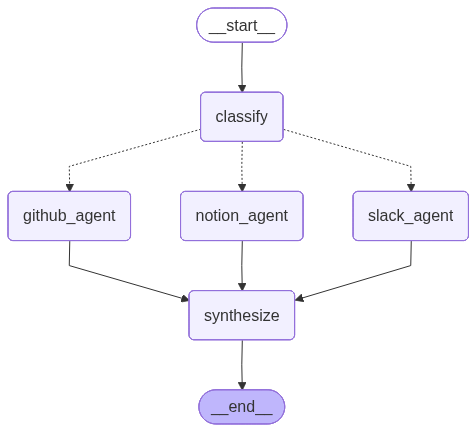

In [58]:
from IPython.display import Image, display

router_graph

## 7. 라우터 그래프 실행

이제 실제로 라우터 그래프를 실행해봐요. 쿼리에 따라 어떤 에이전트들이 호출되는지 관찰해요.

In [59]:

query = "인증 기능 개발 현황이 어떻게 되나요? 코드, 문서, 팀 대화 모두 확인하고 싶다"

print(f"쿼리: {query}")

result = router_graph.invoke({"query": query})

print(result["final_response"])


쿼리: 인증 기능 개발 현황이 어떻게 되나요? 코드, 문서, 팀 대화 모두 확인하고 싶다
[분류기] 쿼리: '인증 기능 개발 현황이 어떻게 되나요? 코드, 문서, 팀 대화 모두 확인하고 싶다'
[분류기] 분류 결과: [('github', '인증 기능 개발 현황'), ('notion', '인증 기능 문서와 프로젝트 노트'), ('slack', '인증 기능 관련 대화 기록')]
[GitHub 에이전트] 쿼리: '인증 기능 개발 현황'
[Notion 에이전트] 쿼리: '인증 기능 문서와 프로젝트 노트'
[Slack 에이전트] 쿼리: '인증 기능 관련 대화 기록'

[합성기] 3개 결과 통합 중...
인증 기능 개발 현황에 대해 다음과 같이 정리할 수 있습니다:

### 1. 개발 현황 (GitHub)
- **기능 구현**: 여러 이슈와 PR이 있으며, 각 기능은 머지된 상태입니다. 예를 들어:
  - `PR #123`: 여러 인증 기능(일반 인증, OAuth, JWT 인증, 로그인 기능)에 대한 구현이 완료되었습니다.
- **오픈 이슈**: 인증 기능 관련 버그 리포트가 생성된 상태로, `Issue #456`가 있습니다.

### 2. 문서 및 가이드 (Notion)
- **설계 문서**: 인증 기능에 대한 설계 문서가 업데이트되었으며, 이는 2025년 1월 15일자입니다.
- **온보딩 가이드**: 최신 온보딩 가이드는 2024년 12월 20일에 업데이트되었습니다.
- **프로젝트 추적**: 현재 인증 기능과 관련하여 3건의 항목이 데이터베이스에 기록되어 있습니다.

### 3. 팀 대화 (Slack)
- **미팅 일정**: 인증 기능 관련 미팅이 2025년 1월 14일 오전 10시에 예정되어 있습니다.
- **배포 완료**: 2025년 1월 13일자로 인증 기능의 배포가 완료되었다고 보고되었습니다.
- **진행 상황**: 팀장에게 인증 기능의 진행 상황에 대한 질문이 있었습니다 (2025년 1월 12일).

### 결론
현재 인증 기능은 활발히 개발 중이며, 여

In [63]:
# ---------------------------------------------------
# 단일 소스 쿼리 실행: 분류기의 선택적 라우팅 확인
# ---------------------------------------------------

# GitHub에만 해당하는 쿼리
github_only_query = "최근 머지된 PR 중 로그인 관련 코드 변경사항이 있나요?"

# ============================================================
print(f"쿼리: {github_only_query}")
# ============================================================

result2 = router_graph.invoke({"query": github_only_query})

# ============================================================
# 최종 응답:
# ============================================================
print(result2["final_response"])


쿼리: 최근 머지된 PR 중 로그인 관련 코드 변경사항이 있나요?
[분류기] 쿼리: '최근 머지된 PR 중 로그인 관련 코드 변경사항이 있나요?'
[분류기] 분류 결과: [('github', 'recently merged pull requests with changes related to login')]
[GitHub 에이전트] 쿼리: 'recently merged pull requests with changes related to login'

[합성기] 1개 결과 통합 중...
최근 병합된 풀 리퀘스트(PR) 중 로그인 관련 코드 변경 사항은 다음과 같습니다:

- **PR #123**: 로그인 기능이 새롭게 구현되었습니다. 이 PR은 현재 병합 상태입니다.

추가적으로, 로그인과 관련된 버그 리포트 이슈도 있으므로 참고하시기 바랍니다:

- **Issue #456**: 현재 열려 있는 로그인 버그 리포트입니다.

또한, 로그인 로직에 관한 커밋 정보는 다음과 같습니다:

- **Commit abc1234**: 로그인 로직 추가와 관련된 커밋입니다.

이 정보를 통해 현재 로그인 관련 변경 사항 및 문제를 확인하실 수 있습니다.


## 8. 스트리밍으로 실행 과정 관찰하기

`stream_mode="updates"`로 실행하면 각 노드의 실행 순서와 결과를 실시간으로 확인할 수 있어요.

> 💡 **핵심 정리**: 스트리밍 출력에서 **GitHub, Notion, Slack 에이전트가 동시에 실행**되는 것을 확인해요. 세 에이전트가 순서를 기다리지 않고 병렬로 처리되므로 전체 실행 시간이 단축돼요.

In [ ]:
# ---------------------------------------------------
# 스트리밍으로 실행 과정 관찰하기
# ---------------------------------------------------

stream_query = "배포 자동화 작업이 어떻게 진행되고 있나요?"

# ============================================================
print(f"쿼리: {stream_query}")
# ============================================================

# stream_mode="updates"로 각 노드의 업데이트를 순서대로 받아요
for chunk in router_graph.stream(
    {"query": stream_query},
    stream_mode="updates"
):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "final_response" in node_output:
            # synthesize 노드의 최종 응답
            print(f"최종 응답 (처음 200자): {node_output['final_response'][:200]}...")
        elif "results" in node_output and node_output["results"]:
            # 에이전트 결과 (처음 100자만 표시)
            for r in node_output["results"]:
                print(f"결과 (처음 100자): {r[:100]}...")
        else:
            # (처리 완료)
            pass



쿼리: 배포 자동화 작업이 어떻게 진행되고 있나요?
[분류기] 쿼리: '배포 자동화 작업이 어떻게 진행되고 있나요?'
[분류기] 분류 결과: [('notion', '배포 자동화 작업 진행 방법에 대한 문서 및 노트'), ('github', '배포 자동화 관련 코드, PR, 이슈 검색'), ('slack', '배포 자동화 작업에 대한 팀 대화 기록 및 공지사항')]

--- 노드: classify ---
[Notion 에이전트] 쿼리: '배포 자동화 작업 진행 방법에 대한 문서 및 노트'
[GitHub 에이전트] 쿼리: '배포 자동화 관련 코드, PR, 이슈 검색'
[Slack 에이전트] 쿼리: '배포 자동화 작업에 대한 팀 대화 기록 및 공지사항'

--- 노드: notion_agent ---
결과 (처음 100자): Notion:
"배포 자동화 작업 진행 방법"에 대한 관련 문서와 노트는 다음과 같습니다:

1. **배포 자동화 작업 진행 방법 설계 문서**
   - 업데이트 날짜: 2025-...

--- 노드: slack_agent ---
결과 (처음 100자): Slack:
배포 자동화 작업에 대한 팀 대화 기록은 다음과 같습니다:

### 배포 자동화 관련 대화
- **#general**: "배포 자동화 관련 미팅 내일 오전 10시" (...

--- 노드: github_agent ---
결과 (처음 100자): Github 
 배포 자동화와 관련된 GitHub 검색 결과는 다음과 같습니다:

### 코드 관련
- **PR #123**: 배포 자동화 code 관련 기능 구현 (merged)...

[합성기] 3개 결과 통합 중...

--- 노드: synthesize ---
최종 응답 (처음 200자): 배포 자동화 작업은 다음과 같은 단계와 방법으로 진행되고 있습니다:

1. **문서 및 가이드 참조**:
   - 배포 자동화 작업에 대한 세부 정보는 Notion에서 제공하는 **진행 방법 설계 문서**와 **온보딩 가이드**에서 확인할 수 있습니다

## 9. 실습: 커스텀 도메인 라우터 만들기

이제 직접 소스 목록과 도구를 수정해서 다른 용도의 라우터를 만들어봐요.

In [65]:
@tool
def search_weather_data(query: str) -> str:
    """도시별 날씨 데이터를 검색해요."""
    return (
        f"[날씨 데이터] '{query}' 관련:\n"
        "- 서울: 맑음, 24도, 강수확률 10%\n"
        "- 부산: 구름 많음, 22도, 강수확률 30%\n"
        "- 제주: 비, 20도, 강수확률 70%"
    )


@tool
def search_news_data(query: str) -> str:
    """최신 뉴스 데이터를 검색해요."""
    return (
        f"[뉴스 데이터] '{query}' 관련:\n"
        "- AI 에이전트 도입 사례 증가\n"
        "- 멀티 에이전트 워크플로우가 기업 자동화의 핵심 패턴으로 부상\n"
        "- 도구 선택 정확도와 비용 관리가 주요 운영 과제로 언급됨"
    )

## 10. 라우터 패턴 vs 다른 패턴 비교

라우터 패턴이 다른 멀티 에이전트 패턴과 어떻게 다른지 비교해봐요.

| 패턴 | 분기 방식 | 실행 방식 | 적합한 상황 |
|------|-----------|-----------|-------------|
| 핸드오프 (Handoffs) | 상태 변수로 다음 에이전트 결정 | 순차 실행 | 작업을 다음 에이전트에게 넘겨야 할 때 |
| **라우터 (Router)** | 분류기가 복수 에이전트 선택 | **병렬 실행** | 여러 소스에서 동시에 정보가 필요할 때 |
| 서브에이전트 (Subagents) | 단일 오케스트레이터가 지시 | 순차/병렬 혼합 | 복잡한 다단계 작업 위임 |
| 스킬 (Skills) | 온디맨드 컨텍스트 로딩 | 단일 에이전트 | 에이전트가 필요할 때 능력 추가 |

> 🔑 **핵심 개념**: 라우터 패턴의 핵심은 **입력 분류 → 병렬 분배 → 결과 합성** 세 단계예요. `Send` API가 병렬 분배를, `operator.add` 리듀서가 결과 집계를 담당해요.

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **라우터 패턴**: 분류 → 병렬 분배 → 합성 3단계로 구성되는 멀티 에이전트 아키텍처예요
- **분류 스키마**: `with_structured_output`으로 도메인별 검색 계획을 안정적으로 받아요
- **`Send` 적용**: Part 02에서 배운 `Send(node_name, state_dict)`를 라우터의 동적 병렬 dispatch에 적용해요
- **`Annotated[list, operator.add]`**: 병렬 실행된 에이전트들의 결과를 덮어쓰지 않고 안전하게 집계해요
- **합성 노드**: 여러 도메인 에이전트의 결과를 LLM으로 통합해 일관된 최종 응답을 생성해요
- **비용 최적화**: 경량 분류기 + 특화 에이전트 조합으로 정확도와 비용을 모두 최적화할 수 있어요

## 다음 노트북 예고

다음 `07-Skills-Pattern.ipynb`에서는 **스킬 패턴(Skills Pattern)**을 배워요. 라우터 패턴이 입력을 보고 에이전트를 선택한다면, 스킬 패턴은 에이전트가 실행 중에 **온디맨드로 필요한 능력을 로딩**하는 방식이에요.
